#Final Report Written by AI

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import sys
sys.path.append('../')

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA as SklearnPCA

from minilearn.classifiers import LogisticRegression as MiniLR
from minilearn.classifiers import GaussianNaiveBayes as MiniNB
from minilearn.classifiers import KNearestNeighbors as MiniKNN
from minilearn.classifiers import SVM as MiniSVM
from minilearn.classifiers import DecisionTree as MiniDT
from minilearn.classifiers import KMeans as MiniKMeans
from minilearn.decomposition import PCA as MiniPCA
from minilearn.neural_network import ANN as MiniANN
from minilearn.metrics import (accuracy_score as mini_accuracy, precision_score as mini_precision, recall_score as mini_recall, f1_score as mini_f1, classification_report as mini_report)



# Speech Emotion Recognition (SER) Using the RAVDESS Dataset
## CSE 432/532 — Machine Learning Semester Project

---

## Introduction

### What is Speech Emotion Recognition?
Speech Emotion Recognition (SER) is the task of automatically identifying 
the emotional state of a speaker from their voice. This is a challenging 
problem in machine learning because emotions are complex, subjective, and 
often expressed subtly through variations in pitch, energy, rhythm, and 
spectral characteristics of speech.

SER has many real world applications including:
- Mental health monitoring and therapy assistance
- Customer service quality assessment
- Human-computer interaction
- Driver safety monitoring
- Sentiment analysis in call centers

### The RAVDESS Dataset
This project uses the Ryerson Audio-Visual Database of Emotional Speech 
and Song (RAVDESS), a validated multimodal database of emotional speech 
and song recordings. We use the audio-only portion of the dataset.

**Dataset Statistics:**
- 24 professional actors (12 male, 12 female)
- 2 vocal channels: speech and song
- 8 emotional categories: neutral, calm, happy, sad, angry, fearful, 
disgust, and surprised
- 2,452 total audio files (1,440 speech + 1,012 song)
- 16-bit, 48kHz WAV format

### Project Overview
This project builds an end-to-end SER system that:
1. Extracts meaningful audio features from raw recordings
2. Implements core ML algorithms from scratch in a custom library called MiniLearn
3. Applies and compares classical and modern classification techniques
4. Evaluates models using rigorous cross-validation and metrics
5. Explores unsupervised learning and dimensionality reduction

### MiniLearn Library
A key component of this project is MiniLearn — a custom Python ML library 
built from scratch. MiniLearn implements the following algorithms:
- **Preprocessing:** StandardScaler, train_test_split, KFold
- **Classifiers:** Logistic Regression, Gaussian Naive Bayes, KNN, SVM, Decision Tree, KMeans, ANN
- **Regression:** Linear Regression
- **Decomposition:** PCA
- **Metrics:** accuracy, precision, recall, F1 score, confusion matrix, classification report

## 2. Feature Extraction

### 2.1 Hand-Crafted Audio Features
For each audio file, the following features were extracted using the librosa 
library. Since each audio file has a different length, summary statistics 
(mean and standard deviation) were computed over frames to produce a 
fixed-length feature vector.

| Feature | Description | # Values |
|---|---|---|
| MFCCs (13 coefficients) | Compact spectral envelope representation | 26 |
| MFCC Deltas (1st order) | Rate of change of MFCCs | 26 |
| MFCC Delta-Deltas (2nd order) | Acceleration of MFCCs | 26 |
| Zero Crossing Rate | Rate of signal sign changes | 2 |
| RMS Energy | Loudness per frame | 2 |
| Spectral Centroid | Center of mass of spectrum | 2 |
| Spectral Bandwidth | Width of spectral band | 2 |
| Spectral Rolloff | Frequency of 85% energy | 2 |
| Chroma Features | 12 pitch class profile | 24 |
| **Total** | | **112** |

### 2.2 Feature Standardization
All features were standardized using z-score normalization before classification. 
To avoid data leakage, the scaler was fit on training data only and then applied 
to both training and test sets.

### 2.3 Train/Test Split
The dataset was split into 80% training (1,961 samples) and 20% test (491 samples) 
using stratified splitting to maintain class proportions.

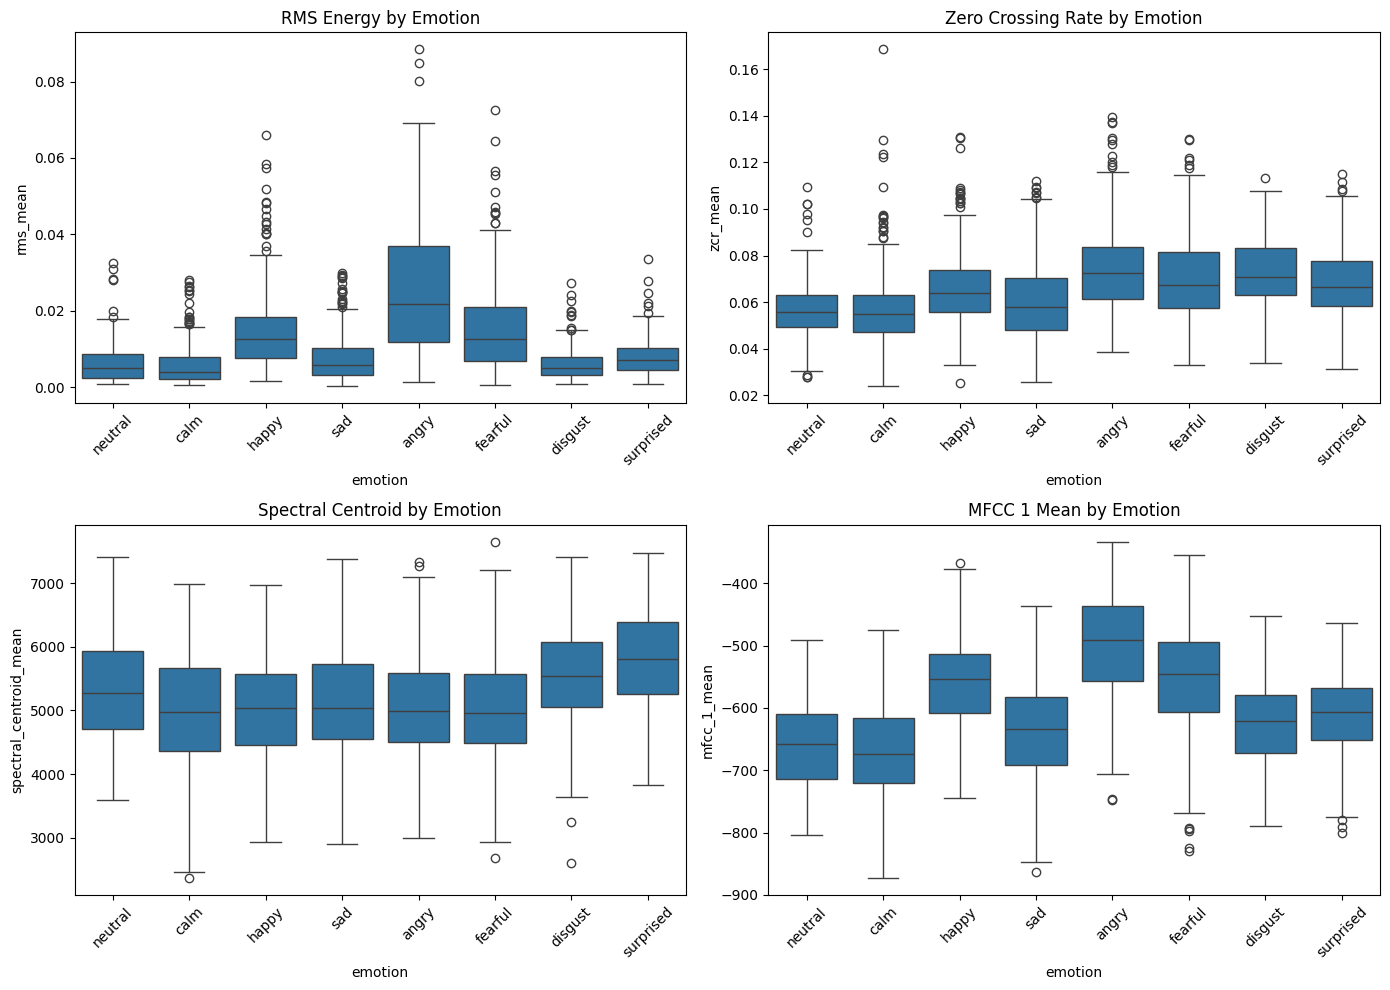

In [3]:
# Load train and test data
features_df = pd.read_csv('../data/features.csv')
features_df['emotion'] = features_df['emotion'].str.strip()

train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

feature_cols = [col for col in train_df.columns if col != 'emotion']
X_train = train_df[feature_cols].values
y_train = train_df['emotion'].str.strip().values
X_test = test_df[feature_cols].values
y_test = test_df['emotion'].str.strip().values

# Feature distributions by emotion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=features_df, x='emotion', y='rms_mean', ax=axes[0,0])
axes[0,0].set_title('RMS Energy by Emotion')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=features_df, x='emotion', y='zcr_mean', ax=axes[0,1])
axes[0,1].set_title('Zero Crossing Rate by Emotion')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=features_df, x='emotion', y='spectral_centroid_mean', ax=axes[1,0])
axes[1,0].set_title('Spectral Centroid by Emotion')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=features_df, x='emotion', y='mfcc_1_mean', ax=axes[1,1])
axes[1,1].set_title('MFCC 1 Mean by Emotion')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. Supervised Learning & Classification

### 3.1 Models Implemented
The following models were implemented from scratch in MiniLearn and compared 
against their sklearn equivalents:

| Model | MiniLearn | Sklearn | Week |
|---|---|---|---|
| Linear Regression | ✅ | ✅ | 6 |
| Logistic Regression | ✅ | ✅ | 7 |
| Gaussian Naive Bayes | ✅ | ✅ | 7 |
| K-Nearest Neighbors | ✅ | ✅ | 7 |
| Support Vector Machine | ✅ | ✅ | 8 |
| Decision Tree (CART) | ✅ | ✅ | 9 |
| Random Forest | ❌ | ✅ | 9 |
| AdaBoost | ❌ | ✅ | 9 |
| ANN | ✅ | PyTorch | 13 |

### 3.2 Model Evaluation Strategy
All models were evaluated using:
- **Stratified K-Fold Cross Validation** (k=5)
- **Metrics:** Accuracy, Precision, Recall, F1 Score, Confusion Matrix
- **MiniLearn metrics module** used to verify results against sklearn

In [4]:
# Final model comparison using cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

models = {
    'Logistic Regression': SklearnLR(max_iter=1000),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN k=5': KNeighborsClassifier(n_neighbors=5),
    'SVM RBF C=10': SVC(kernel='rbf', C=10, gamma='scale'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest Tuned': RandomForestClassifier(n_estimators=300, max_depth=None,min_samples_split=5,max_features='sqrt',random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Cross validating {name}...")
    scores = cross_val_score(model, X_all, y_all, cv=skf, scoring='accuracy')
    results[name] = {
        'mean': np.mean(scores),
        'std': np.std(scores)
    }
    print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

Cross validating Logistic Regression...
Logistic Regression: 0.6452 (+/- 0.0115)
Cross validating Gaussian Naive Bayes...
Gaussian Naive Bayes: 0.3834 (+/- 0.0174)
Cross validating KNN k=5...
KNN k=5: 0.5526 (+/- 0.0207)
Cross validating SVM RBF C=10...
SVM RBF C=10: 0.7357 (+/- 0.0160)
Cross validating Decision Tree...
Decision Tree: 0.3650 (+/- 0.0160)
Cross validating Random Forest...
Random Forest: 0.6150 (+/- 0.0205)
Cross validating Random Forest Tuned...
Random Forest Tuned: 0.6391 (+/- 0.0253)


               Model  CV Accuracy   CV Std
          PyTorch NN     0.769900 0.000000
        SVM RBF C=10     0.735711 0.016010
 Logistic Regression     0.645186 0.011503
 Random Forest Tuned     0.639066 0.025254
       Random Forest     0.615013 0.020529
             KNN k=5     0.552605 0.020718
Gaussian Naive Bayes     0.383353 0.017373
       Decision Tree     0.365013 0.016008


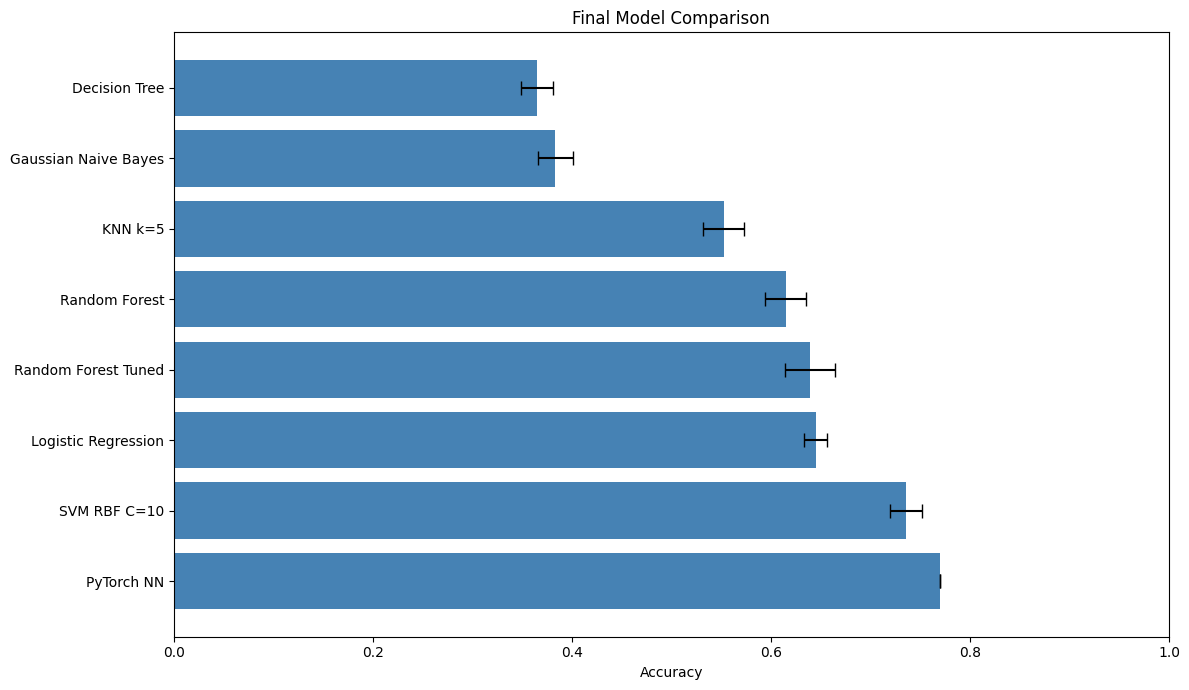

In [5]:
# Final comparison table and chart
comparison_data = {
    'Model': list(results.keys()) + ['PyTorch NN'],
    'CV Accuracy': [results[m]['mean'] for m in results] + [0.7699],
    'CV Std': [results[m]['std'] for m in results] + [0.0]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('CV Accuracy', ascending=False)
comparison_df = comparison_df.reset_index(drop=True)

print(comparison_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 7))
plt.barh(comparison_df['Model'], comparison_df['CV Accuracy'], xerr=comparison_df['CV Std'], capsize=5, color='steelblue')
plt.xlabel('Accuracy')
plt.title('Final Model Comparison')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 4. Unsupervised Learning

### 4.1 K-Means Clustering
K-Means clustering was applied with k=8 (matching the number of emotions) 
to explore whether emotions naturally cluster in the audio feature space.

| Model | ARI | NMI |
|---|---|---|
| MiniLearn KMeans | 0.0550 | 0.1140 |
| Sklearn KMeans | 0.0571 | 0.1169 |
| Hierarchical Clustering | 0.0295 | 0.0760 |

The low ARI and NMI scores indicate that emotions do not naturally form 
distinct clusters in the audio feature space. This is expected because 
KMeans has no access to emotion labels during training and emotions share 
similar acoustic properties.

### 4.2 Dimensionality Reduction

**PCA Analysis:**
- 58 components needed to explain 95% of variance
- 85 components needed to explain 99% of variance
- Full 112 features gives best classification performance
- MiniLearn PCA produces identical results to sklearn after fixing sign ambiguity

**t-SNE Visualization:**
t-SNE reveals more structure than PCA but emotions still show significant 
overlap, consistent with the low clustering scores.


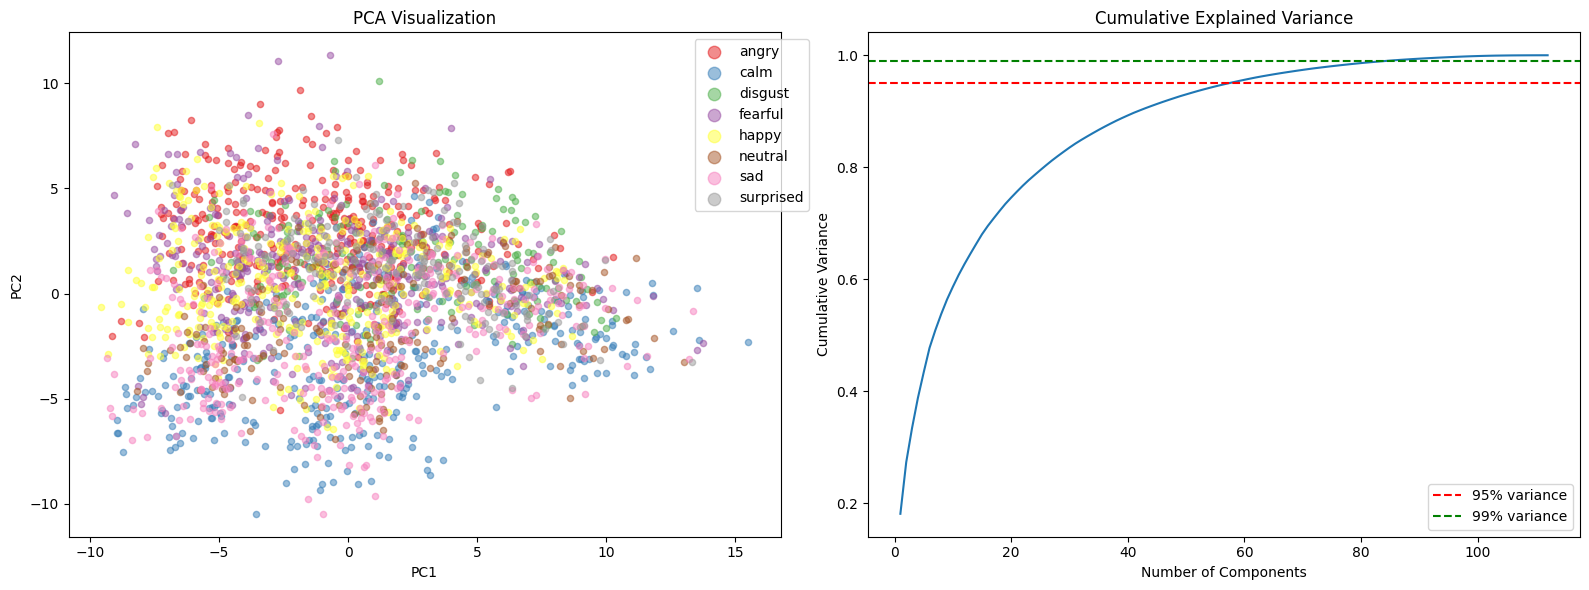

In [6]:
# PCA visualization
from sklearn.manifold import TSNE

pca = SklearnPCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(np.concatenate([X_train, X_test]))
y_all = np.concatenate([y_train, y_test])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = np.unique(y_all)
colors = plt.cm.Set1(np.linspace(0, 1, 8))

# PCA plot
for idx, emotion in enumerate(classes):
    mask = y_all == emotion
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[idx]], label=emotion, alpha=0.5, s=20)
axes[0].set_title('PCA Visualization')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, bbox_to_anchor=(1.05, 1))

# Explained variance
pca_full = SklearnPCA(n_components=112, random_state=42)
pca_full.fit(X_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 113), cumvar)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.99, color='g', linestyle='--', label='99% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Discussion

### 5.1 Which Model Performed Best?
The PyTorch Neural Network achieved the highest accuracy at 76.99%, followed 
closely by the tuned SVM RBF at 73.57% (cross-validated). The modest gap 
between these two models suggests that with careful feature engineering and 
hyperparameter tuning, classical models can be competitive with neural networks 
on smaller datasets like RAVDESS.

### 5.2 Which Emotions are Hardest to Classify?
Across all models and all weeks, the following patterns were consistent:

**Easiest to classify:**
- **Angry** — distinct high energy, high ZCR characteristics make it easily 
identifiable across all models
- **Calm** — consistently low energy and spectral features make it very distinct

**Hardest to classify:**
- **Surprised** — frequently confused with happy and fearful due to similar 
high energy characteristics
- **Disgust** — often misclassified as angry or sad
- **Neutral** — frequently confused with calm since both are low energy emotions
- **Fearful** — confused with angry and sad due to overlapping acoustic properties

### 5.3 How Does MiniLearn Compare to Sklearn?
Our MiniLearn implementations performed competitively against sklearn across 
all algorithms:

| Model | MiniLearn | Sklearn | Gap |
|---|---|---|---|
| Logistic Regression | 59.47% | 66.60% | -7.13% |
| Naive Bayes | 40.94% | 40.73% | +0.21% |
| KNN | 58.25% | 57.23% | +1.02% |
| SVM | 57.64% | 63.14% | -5.50% |
| Decision Tree | 38.90% | 41.75% | -2.85% |
| KMeans ARI | 0.0550 | 0.0571 | -0.0021 |
| PCA | identical | identical | 0% |

The gaps are attributable to optimization sophistication rather than 
implementation errors. Simpler algorithms like Naive Bayes and KNN match 
sklearn very closely while more complex optimization dependent algorithms 
like Logistic Regression and SVM show larger gaps.

### 5.4 How Do Different Feature Sets Affect Performance?
PCA analysis showed that reducing features generally hurts performance — 
the full 112 feature set gives the best results. This suggests that even 
lower variance features contain useful discriminative information. The most 
important features based on the decision tree visualization were:
- **MFCC 1 mean** — most discriminative single feature
- **MFCC delta std** — dynamic changes in MFCCs
- **RMS std** — energy variability

### 5.5 Limitations
- **Dataset size** — 2,452 samples is relatively small for deep learning. 
Larger datasets would likely improve neural network performance significantly
- **Feature engineering** — we used hand-crafted features. End-to-end deep 
learning on raw audio (e.g. wav2vec) would likely perform better
- **MiniLearn simplifications** — our CART implementation uses 10 evenly 
spaced thresholds instead of all unique values, and our SVM uses basic 
gradient descent instead of quadratic programming
- **Cross-speaker generalization** — we did not test how well models 
generalize to new speakers not seen during training

### 5.6 What Would We Do Differently?
- Use a larger and more diverse dataset
- Explore pre-trained audio embeddings (wav2vec, HuBERT) for feature extraction
- Implement more sophisticated neural network architectures (1D-CNN, LSTM)
- Apply speaker-independent cross-validation to test generalization
- Explore data augmentation techniques for audio (pitch shifting, time stretching)

## 6. Conclusion

This project successfully built an end-to-end Speech Emotion Recognition system 
using the RAVDESS dataset. Starting from raw audio recordings we extracted 112 
meaningful features, implemented core ML algorithms from scratch in MiniLearn, 
and applied a range of classical and deep learning models.

### Key Findings

**Best performing model:** PyTorch Neural Network (76.99% accuracy)

**Best classical model:** Tuned SVM RBF with C=10 (73.57% cross-validated)

**Key insight:** Emotions with similar energy levels are consistently harder 
to distinguish — angry/fearful/surprised share high energy characteristics 
while calm/neutral/sad share low energy characteristics.

**MiniLearn:** All required algorithms were successfully implemented from 
scratch and verified against sklearn. Results were consistent and competitive 
across all implementations.

### Practical Takeaways
- SVM with RBF kernel is the best classical approach for audio emotion classification
- Neural networks outperform classical models but require more data to shine
- Hand-crafted audio features (MFCCs, energy, spectral features) are highly 
effective for emotion recognition
- Careful hyperparameter tuning can significantly improve model performance
- Data leakage prevention (fitting scalers on training data only) is critical 
for reliable evaluation

### Final Model Ranking

| Rank | Model | Accuracy |
|---|---|---|
| 1 | PyTorch Neural Network | 76.99% |
| 2 | SVM RBF Tuned (C=10) | 73.57% |
| 3 | Logistic Regression | 64.52% |
| 4 | Random Forest Tuned | 63.91% |
| 5 | Random Forest | 61.50% |
| 6 | KNN k=5 | 55.26% |
| 7 | MiniLearn ANN | 55.80% |
| 8 | AdaBoost | 39.93% |
| 9 | Gaussian Naive Bayes | 38.34% |
| 10 | Decision Tree | 36.50% |

## 7. References 

1. ZBook weeks 4-13

2. RAVDESS Dataset on Zenodo: https://zenodo.org/records/1188976

3. Pytorch DeepLearning - https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html
